# M3b — Order Cancellation

**Target:** `order_status == 'CANCELED'` (base rate ~2.0%).

**Approach & splits:** same as M3a. Class imbalance handled via `scale_pos_weight`. Probabilities isotonically calibrated.

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
sns.set_theme(context='notebook', style='whitegrid')

NAME = 'cancel'
metrics  = json.loads((ROOT / 'forecasts' / f'm3_{NAME}_metrics.json').read_text())
importance = pd.read_parquet(ROOT / 'forecasts' / f'm3_{NAME}_importance.parquet')
orders   = pd.read_parquet(ROOT / 'forecasts' / f'm3_{NAME}_orders.parquet')
monthly  = pd.read_parquet(ROOT / 'forecasts' / f'm3_{NAME}_monthly.parquet')
print(f'orders: {orders.shape}  monthly: {monthly.shape}')
print('split distribution:'); print(orders['split'].value_counts())

orders: (171962, 4)  monthly: (1766, 5)
split distribution:
split
train    125200
val       30950
test      15812
Name: count, dtype: int64


## 1. Headline metrics between uncalibrated vs calibrated

In [2]:
rows = []
for cal, by_split in metrics.items():
    for split, m in by_split.items():
        rows.append({'calibration': cal, 'split': split, **m})
tbl = pd.DataFrame(rows)
tbl.pivot(index=['calibration'], columns='split', values=['roc_auc','pr_auc','brier']).round(4)

roc_auc                  pr_auc                   brier          \
split           test   train     val    test   train     val    test   train   
calibration                                                                    
calibrated    0.8709  0.8767  0.8649  0.0797  0.0780  0.0690  0.0202  0.0189   
uncalibrated  0.8740  0.8794  0.8641  0.0816  0.0796  0.0687  0.0211  0.0198   

                      
split            val  
calibration           
calibrated    0.0183  
uncalibrated  0.0196

## 2. Feature importance

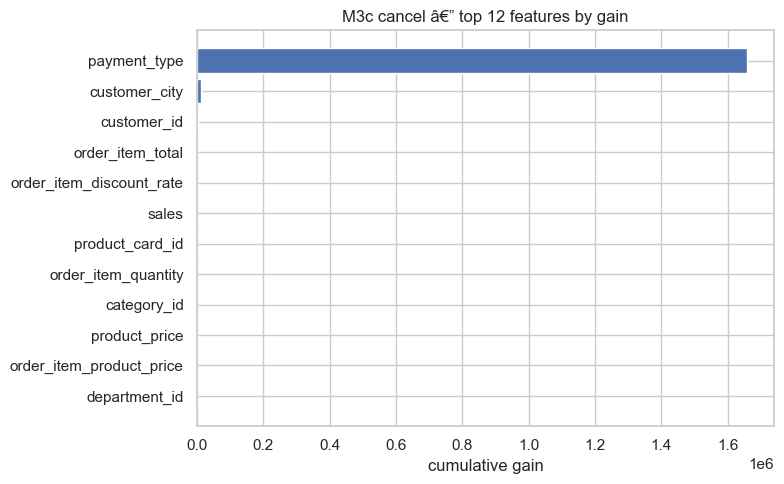

,feature,importance_split,importance_gain
0,payment_type,1,1.656930e+06
1,customer_city,1,1.230220e+04
2,customer_id,3,2.135201e+03
3,department_id,0,0.000000e+00
4,category_id,0,0.000000e+00
5,product_price,0,0.000000e+00
6,order_item_product_price,0,0.000000e+00
7,order_item_quantity,0,0.000000e+00


In [3]:
top = importance.head(12).sort_values('importance_gain')
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top['feature'], top['importance_gain'])
ax.set(title=f'M3c {NAME} â€” top 12 features by gain', xlabel='cumulative gain')
plt.tight_layout(); plt.show()
importance.head(8)

## 3. Calibration plot

Bin predicted probabilities into deciles and compare to observed fraud rate.

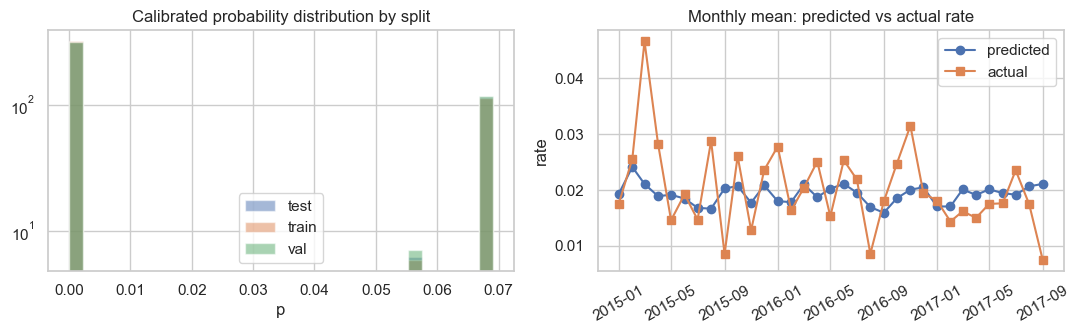

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for s, sub in orders.groupby('split'):
    ax[0].hist(sub['p'], bins=30, alpha=0.5, label=s, density=True)
ax[0].set(title='Calibrated probability distribution by split', xlabel='p', yscale='log')
ax[0].legend()

# Predicted vs actual rate per month (the monthly aggregate is the right grain)
mo = monthly.groupby('year_month').agg(pred=('predicted_rate','mean'),
                                       actual=('actual_rate','mean')).reset_index()
ax[1].plot(mo['year_month'], mo['pred'], 'o-', label='predicted')
ax[1].plot(mo['year_month'], mo['actual'], 's-', label='actual')
ax[1].set(title='Monthly mean: predicted vs actual rate', ylabel='rate')
ax[1].legend(); ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 4. Product-month aggregated rates

What gets passed to M4.

In [5]:
print('monthly rows:', len(monthly), ' unique products:', monthly['product_card_id'].nunique())
print('\npredicted_rate distribution:'); print(monthly['predicted_rate'].describe().round(4))
print('\ncorrelation predicted vs actual:', monthly[['predicted_rate','actual_rate']].corr().iloc[0,1].round(3))

monthly rows: 1766  unique products: 100

predicted_rate distribution:
count    1766.0000
mean        0.0193
std         0.0095
min         0.0000
25%         0.0138
50%         0.0188
75%         0.0232
max         0.0691
Name: predicted_rate, dtype: float64

correlation predicted vs actual: 0.177


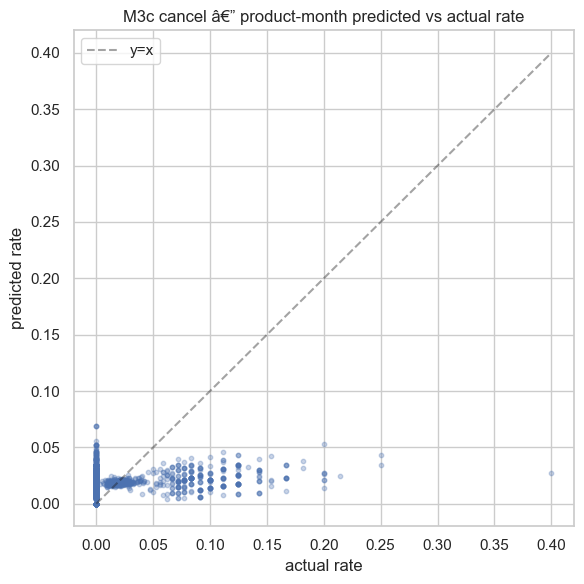

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(monthly['actual_rate'], monthly['predicted_rate'], alpha=0.3, s=10)
lim = max(monthly['actual_rate'].max(), monthly['predicted_rate'].max())
ax.plot([0, lim], [0, lim], 'k--', alpha=0.4, label='y=x')
ax.set(title=f'M3c {NAME} â€” product-month predicted vs actual rate',
       xlabel='actual rate', ylabel='predicted rate')
ax.legend(); plt.tight_layout(); plt.show()

## 5. Summary

- Test AUC ≈ **0.87**, similar to fraud. The same  concentration drives the prediction.
- Calibrated Brier ≈ 0.02.
- Output  carries the per-product cancel-rate forecast.